In [32]:
import torch
import matplotlib.pyplot as plt 

import numpy as np
from PIL import Image
from pathlib import Path

from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models




### Split train valid test

In [1]:
# Using indices to create subset of dataset

from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

In [37]:
DATA_DIR = Path("../data/Otoscopic_Data")

full_dataset = datasets.ImageFolder(
    root=DATA_DIR
)


print(full_dataset.classes)
print(full_dataset.class_to_idx)
print(len(full_dataset))

['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
{'Acute Otitis Media': 0, 'Cerumen Impaction': 1, 'Chronic Otitis Media': 2, 'Myringosclerosis': 3, 'Normal': 4}
3000


In [38]:


targets = full_dataset.targets
all_indices = list(range(len(full_dataset)))

train_indices, temporary_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    stratify=targets,
)


temporary_targets = [targets[index] for index in temporary_indices]

valid_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=0.50,
    random_state=42,
    stratify=temporary_targets,
)

### Training and dataset configs

DEFINE TRANSFORMS

In [39]:
#using imagenet pretrained expected mean and std values for normalization
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD)
    ])
valid_transform =  transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD)
    ])
test_transform =  transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD)
  ])




In [40]:
train_full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform,
)

valid_full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=valid_transform,
)

test_full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=test_transform,
)

train_dataset = Subset(train_full_dataset, train_indices)
valid_dataset = Subset(valid_full_dataset, valid_indices)
test_dataset = Subset(test_full_dataset, test_indices)

CREATE DATA LOADERS

In [41]:
# from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

In [42]:
print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Training images: 2100
Validation images: 450
Test images: 450
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [43]:
print(train_full_dataset.classes)
print(train_full_dataset.class_to_idx)

['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
{'Acute Otitis Media': 0, 'Cerumen Impaction': 1, 'Chronic Otitis Media': 2, 'Myringosclerosis': 3, 'Normal': 4}


## TRAIN

In [44]:
	
# Load the pre-trained ResNet18 <model.

from torchvision.models import resnet18, ResNet18_Weights


weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

print(model.fc)

# Freeze all pretrained ResNet parameters
for parameter in model.parameters():
    parameter.requires_grad = False

num_classes = len(train_full_dataset.classes) #AKA 5 classes
# Replace the final fully connected layer with one w/ correct # output classes
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)



Linear(in_features=512, out_features=1000, bias=True)


TRAINING PIPELINE

In [46]:
import os


def create_checkpoint_dir(checkpoint_dir):

    # Create a new checkpoint directory every time.
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    print(f"Checkpoint directory: {checkpoint_dir}")
    return checkpoint_dir

SET UP TRAINING MODE

In [51]:
def train(model,optimizer,train_loader,device):
    #model.train()
    model.eval()
    model.fc.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = torch.nn.functional.cross_entropy(outputs, labels)

        loss.backward()
        optimizer.step()

        # Sample-weighted loss
        running_loss += loss.item() * images.size(0)

        # Calculate predictions
        predicted_labels = outputs.argmax(dim=1)

        # Count correct predictions
        correct_predictions += (
            predicted_labels == labels
        ).sum().item()

        # Count samples
        total_samples += images.size(0)

    #avg loss over the entire epoch
    # epoch_loss = running_loss / len(train_loader)

    epoch_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples


    return epoch_loss, accuracy

In [52]:
def save_checkpoint(
    model,
    optimizer,
    epoch,
    valid_loss,
    valid_accuracy,
    checkpoint_dir
):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        "best_model.pth"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "valid_loss": valid_loss,
            "valid_accuracy": valid_accuracy,
            "class_names": train_full_dataset.classes,
        },
        checkpoint_path
    )

    print(f"Best checkpoint saved at: {checkpoint_path}")

In [53]:
from torch.nn.functional import cross_entropy
def validate(model, valid_loader, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = cross_entropy(outputs, labels)
            running_loss += loss.item() * images.size(0)

            predicted_labels = outputs.argmax(dim=1)

            correct_predictions += (
                predicted_labels == labels
            ).sum().item()

            total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return epoch_loss, accuracy

In [54]:
def main():
   #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    model.to(device)

    #optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001) # bc training final layer only

    checkpoint_dir = create_checkpoint_dir("checkpoints")

    #num_epochs = 10
    num_epochs = 10 #FOR TESTING PURPOSES
    best_valid_loss = float("inf")

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, optimizer, train_loader, device)
        valid_loss, valid_accuracy = validate(model, valid_loader, device)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, "
              f"Train Accuracy: {train_accuracy:.4f}, "
              f"Valid Loss: {valid_loss:.4f}, "
              f"Valid Accuracy: {valid_accuracy:.4f}")

        #save_checkpoint(model, optimizer, epoch + 1, checkpoint_dir)    
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss

            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch + 1,
                valid_loss=valid_loss,
                valid_accuracy=valid_accuracy,
                checkpoint_dir=checkpoint_dir
            )
            

PRE RUN TEST

In [55]:
# import torch

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

PyTorch version: 2.13.0
MPS available: True
MPS built: True


In [56]:
main()

Checkpoint directory: checkpoints
Epoch [1/10], Train Loss: 0.7708, Train Accuracy: 0.7429, Valid Loss: 0.3999, Valid Accuracy: 0.8911
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [2/10], Train Loss: 0.3301, Train Accuracy: 0.9086, Valid Loss: 0.2562, Valid Accuracy: 0.9289
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [3/10], Train Loss: 0.2405, Train Accuracy: 0.9381, Valid Loss: 0.2028, Valid Accuracy: 0.9378
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [4/10], Train Loss: 0.1937, Train Accuracy: 0.9467, Valid Loss: 0.1729, Valid Accuracy: 0.9556
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [5/10], Train Loss: 0.1684, Train Accuracy: 0.9548, Valid Loss: 0.1497, Valid Accuracy: 0.9444
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [6/10], Train Loss: 0.1473, Train Accuracy: 0.9624, Valid Loss: 0.1289, Valid Accuracy: 0.9578
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [7/10], Train Loss: 0.1287, Train Ac

### EVALUATE

In [57]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

 

checkpoint_path = "checkpoints/best_model.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Validation loss: {checkpoint['valid_loss']:.4f}")
print(f"Validation accuracy: {checkpoint['valid_accuracy']:.4f}")

Loaded checkpoint from epoch 9
Validation loss: 0.1015
Validation accuracy: 0.9711


In [58]:
test_loss, test_accuracy = validate(
    model,
    test_loader,
    device
)

print(
    f"Test Loss: {test_loss:.4f}, "
    f"Test Accuracy: {test_accuracy:.4f}"
)

Test Loss: 0.1189, Test Accuracy: 0.9733


In [59]:
import matplotlib.pyplot as plt
import torch

# ImageNet normalization values used by pretrained ResNet18
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMG_STD = torch.tensor([0.229, 0.224, 0.225])


def denormalize_image(image):
    """
    Reverse ImageNet normalization for visualization.

    image shape: [channels, height, width]
    """
    image = image.cpu()

    mean = IMG_MEAN[:, None, None]
    std = IMG_STD[:, None, None]

    image = image * std + mean

    # Keep pixel values in the valid display range
    return image.clamp(0, 1)


def show_test_predictions(
    model,
    test_loader,
    device,
    class_names,
    number_of_images=12
):
    model.eval()

    # Get one batch from the test loader
    images, labels = next(iter(test_loader))

    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        predicted_labels = outputs.argmax(dim=1)

    number_of_images = min(number_of_images, images.size(0))

    columns = 4
    rows = (number_of_images + columns - 1) // columns

    plt.figure(figsize=(14, 3.5 * rows))

    for index in range(number_of_images):
        image = denormalize_image(images[index])

        # Convert from [C, H, W] to [H, W, C]
        image = image.permute(1, 2, 0)

        true_index = labels[index].item()
        predicted_index = predicted_labels[index].item()

        true_name = class_names[true_index]
        predicted_name = class_names[predicted_index]

        correct = true_index == predicted_index
        result = "Correct" if correct else "Incorrect"

        plt.subplot(rows, columns, index + 1)
        plt.imshow(image)
        plt.title(
            f"{result}\n"
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [60]:
import matplotlib.pyplot as plt
import torch

# ImageNet normalization values used by pretrained ResNet18
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMG_STD = torch.tensor([0.229, 0.224, 0.225])


def denormalize_image(image):
    """
    Reverse ImageNet normalization for visualization.

    image shape: [channels, height, width]
    """
    image = image.cpu()

    mean = IMG_MEAN[:, None, None]
    std = IMG_STD[:, None, None]

    image = image * std + mean

    # Keep pixel values in the valid display range
    return image.clamp(0, 1)


def show_test_predictions(
    model,
    test_loader,
    device,
    class_names,
    number_of_images=12
):
    model.eval()

    # Get one batch from the test loader
    images, labels = next(iter(test_loader))

    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        predicted_labels = outputs.argmax(dim=1)

    number_of_images = min(number_of_images, images.size(0))

    columns = 4
    rows = (number_of_images + columns - 1) // columns

    plt.figure(figsize=(14, 3.5 * rows))

    for index in range(number_of_images):
        image = denormalize_image(images[index])

        # Convert from [C, H, W] to [H, W, C]
        image = image.permute(1, 2, 0)

        true_index = labels[index].item()
        predicted_index = predicted_labels[index].item()

        true_name = class_names[true_index]
        predicted_name = class_names[predicted_index]

        correct = true_index == predicted_index
        result = "Correct" if correct else "Incorrect"

        plt.subplot(rows, columns, index + 1)
        plt.imshow(image)
        plt.title(
            f"{result}\n"
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

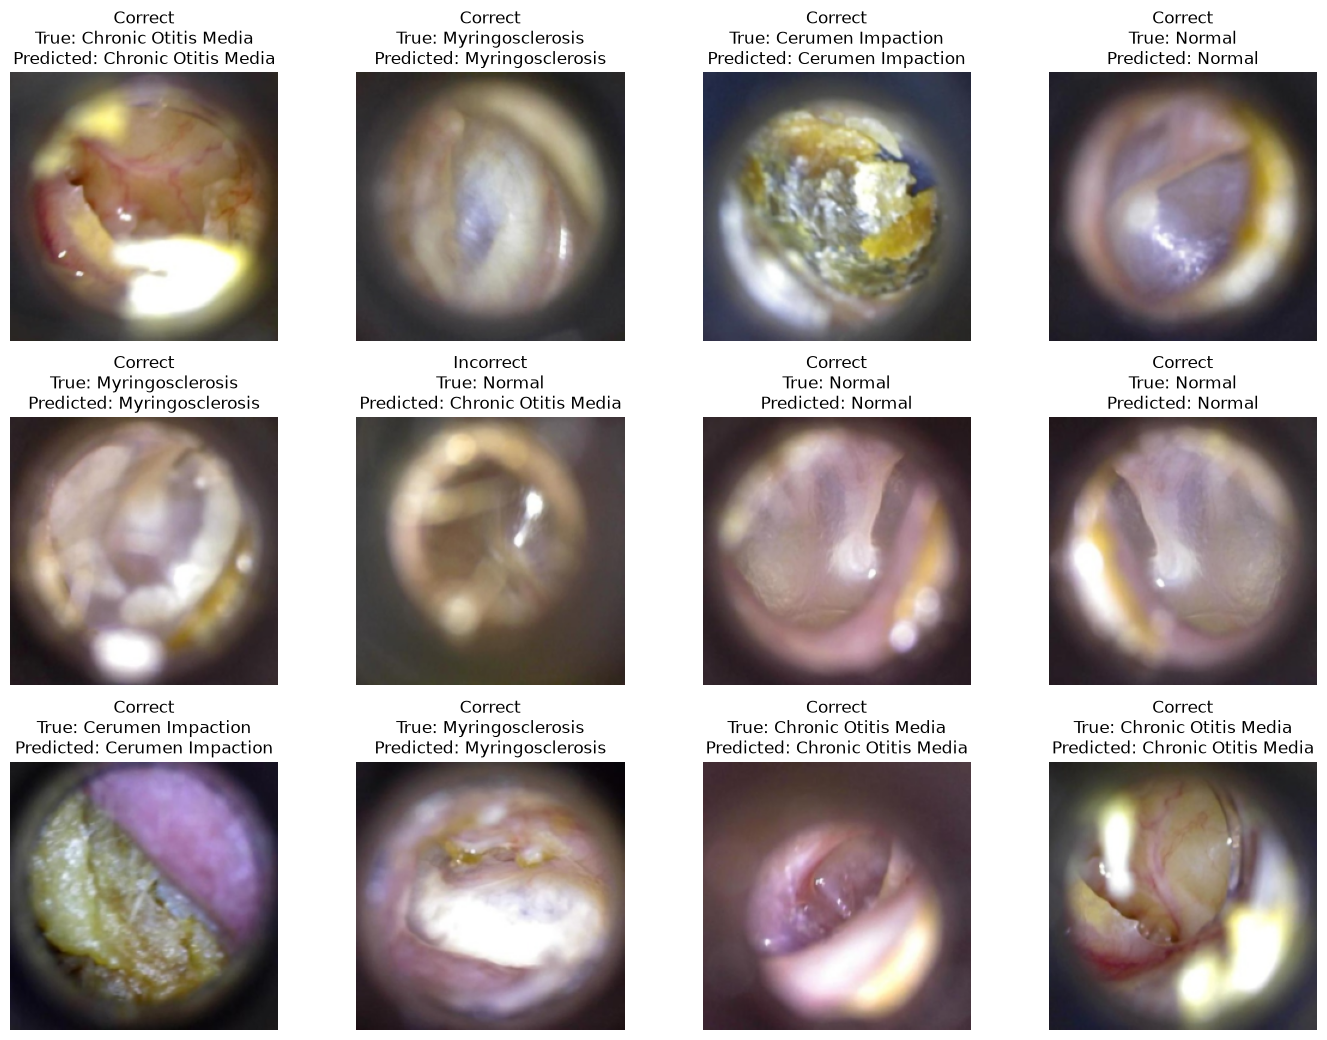

In [61]:
class_names = full_dataset.classes

show_test_predictions(
    model=model,
    test_loader=test_loader,
    device=device,
    class_names=class_names,
    number_of_images=12
)

### Grad CAM analysis

In [62]:
checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")

Loaded checkpoint from epoch 9


In [63]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [64]:
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMG_STD = torch.tensor([0.229, 0.224, 0.225])


def denormalize_image(image):
    image = image.detach().cpu()

    mean = IMG_MEAN[:, None, None]
    std = IMG_STD[:, None, None]

    image = image * std + mean
    return image.clamp(0, 1)


def show_gradcam(
    model,
    image,
    true_label,
    class_names,
    device
):
    model.eval()

    # Add batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    #input_tensor = image.unsqueeze(0).to(device)
    input_tensor = (
        image.unsqueeze(0)
        .to(device)
        .clone()
        .detach()
        .requires_grad_(True)
    )


    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_index = outputs.argmax(dim=1).item()

    # Last convolutional block of ResNet18
    target_layers = [model.layer4[-1]]

    # Generate Grad-CAM for the predicted class
    targets = [
        ClassifierOutputTarget(predicted_index)
    ]

    with GradCAM(
        model=model,
        target_layers=target_layers
    ) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

    # Reverse normalization for display
    display_image = denormalize_image(image)
    display_image = display_image.permute(1, 2, 0).numpy()

    # Overlay heatmap onto the original image
    cam_overlay = show_cam_on_image(
        display_image.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    true_name = class_names[true_label]
    predicted_name = class_names[predicted_index]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(display_image)
    plt.title(f"Original\nTrue: {true_name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cam_overlay)
    plt.title(f"Grad-CAM\nPredicted: {predicted_name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

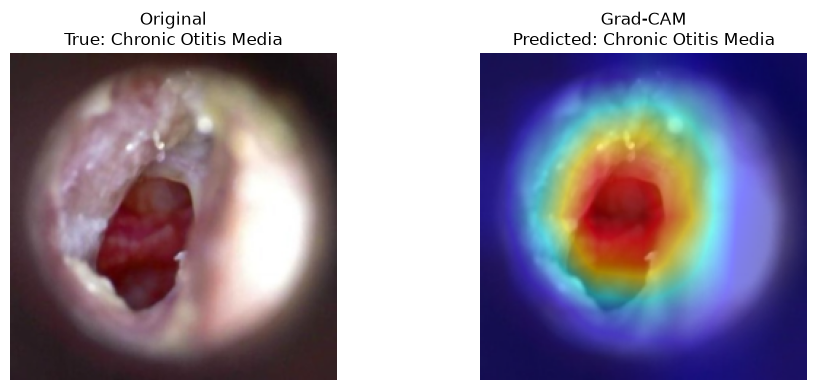

In [69]:
test_image, test_label = test_dataset[190]

show_gradcam(
    model=model,
    image=test_image,
    true_label=test_label,
    class_names=full_dataset.classes,
    device=device
)

